# EDA — Calidad del Aire Madrid

Análisis exploratorio del dataset histórico de calidad del aire de Madrid (2025-2026).  
**Dataset**: 24 estaciones, 11 contaminantes, mediciones horarias.  
**Fichero**: `data/processed/aire_madrid_maestro.csv` (resultado del ETL en `src/etl/limpiar_datos.py`)

---
**Índice**
1. Carga y visión general
2. Cobertura por estación y contaminante
3. Patrones temporales (hora, día, mes)
4. Conclusiones

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Estilo global
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 90
plt.rcParams['figure.figsize'] = (12, 5)
COLORES_CONTAMINANTES = {
    'NO2':  '#e74c3c',
    'NOx':  '#c0392b',
    'NO':   '#e67e22',
    'O3':   '#2980b9',
    'PM10': '#8e44ad',
    'PM2.5':'#6c3483',
    'CO':   '#27ae60',
    'SO2':  '#f39c12',
    'BEN':  '#1abc9c',
    'TOL':  '#16a085',
    'EBE':  '#2ecc71',
}
CONTAMINANTES_PRINCIPALES = ['NO2', 'PM10', 'PM2.5', 'O3', 'NOx', 'CO', 'SO2']

---
## 1. Carga y visión general

In [3]:
df = pd.read_csv('../data/processed/aire_madrid_maestro.csv', parse_dates=['fecha_hora'])
df_est = pd.read_csv('../data/raw/estaciones-de-control.csv', sep=';', encoding='latin-1')

print(f"Filas:        {df.shape[0]:,}")
print(f"Columnas:     {df.shape[1]}")
print(f"Período:      {df['fecha_hora'].min().date()} > {df['fecha_hora'].max().date()}")
print(f"Estaciones:   {df['nombre_estacion'].nunique()}")
print(f"Contaminantes:{df['contaminante'].nunique()}")
print(f"Nulos:        {df.isnull().sum().sum()}")
df.head()

Filas:        1,207,368
Columnas:     8
Período:      2025-01-01 > 2026-01-31
Estaciones:   24
Contaminantes:11
Nulos:        0


,fecha_hora,hora,dia_semana,mes,es_fin_semana,nombre_estacion,contaminante,valor
0,2025-01-01 00:00:00,0,2,1,False,Arturo Soria,NOx,17.0
1,2025-01-01 00:00:00,0,2,1,False,Arturo Soria,O3,30.0
2,2025-01-01 00:00:00,0,2,1,False,Arturo Soria,NO,2.0
3,2025-01-01 00:00:00,0,2,1,False,Arturo Soria,NO2,14.0
4,2025-01-01 01:00:00,1,2,1,False,Arturo Soria,NOx,41.0


In [23]:
df.dtypes

fecha_hora         datetime64[us]
hora                        int64
dia_semana                  int64
mes                         int64
es_fin_semana                bool
nombre_estacion               str
contaminante                  str
valor                     float64
dtype: object

In [24]:
print('Contaminantes disponibles:')
print(sorted(df['contaminante'].unique()))
print('\nEstaciones disponibles:')
print(sorted(df['nombre_estacion'].unique()))

Contaminantes disponibles:
['BEN', 'CO', 'EBE', 'NO', 'NO2', 'NOx', 'O3', 'PM10', 'PM2.5', 'SO2', 'TOL']

Estaciones disponibles:
['Arturo Soria', 'Barajas Pueblo', 'Barrio del Pilar', 'Casa de Campo', 'Castellana', 'Cuatro Caminos', 'El Pardo', 'Ensanche de Vallecas', 'Escuelas Aguirre', 'Farolillo', 'Juan Carlos I', 'Moratalaz', 'Méndez Álvaro', 'Parque del Retiro', 'Plaza Castilla', 'Plaza Elíptica', 'Plaza de España', 'Plaza del Carmen', 'Ramón y Cajal', 'Sanchinarro', 'Tres Olivos', 'Urb. Embajada', 'Vallecas', 'Villaverde']


---
## 2. Cobertura por estación y contaminante

No todas las estaciones miden todos los contaminantes. Este heatmap muestra qué mide cada una.

Período:      2025-01-01 > 2026-01-31


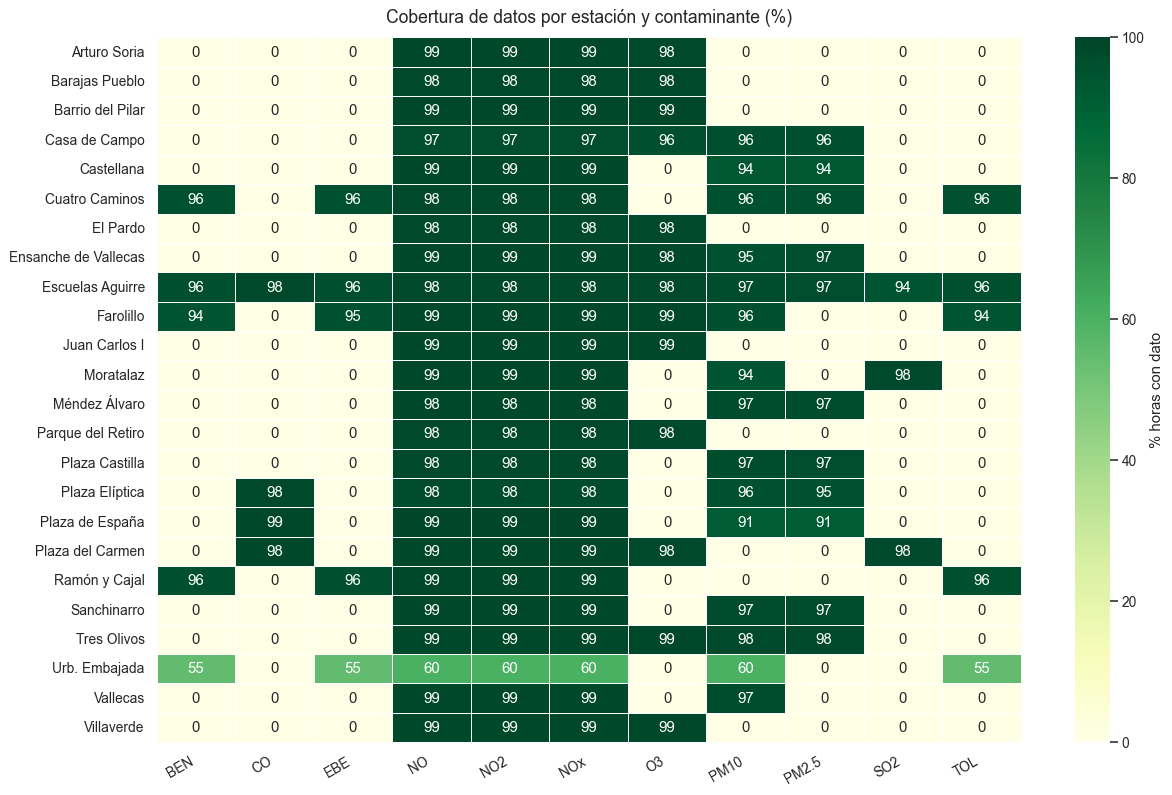


Total horas en el período: 9,504


In [28]:
# Tabla de cobertura: % de horas con dato por estación × contaminante
# Total horas posibles en el período
print(f"Período:      {df['fecha_hora'].min().date()} > {df['fecha_hora'].max().date()}")
n_horas = int((df['fecha_hora'].max() - df['fecha_hora'].min()).total_seconds() / 3600) + 1

cobertura = (
    df.groupby(['nombre_estacion', 'contaminante'])['valor']
    .count()
    .unstack(fill_value=0)
    / n_horas * 100
)

fig, ax = plt.subplots(figsize=(14, 9))
sns.heatmap(
    cobertura,
    annot=True, fmt='.0f', cmap='YlGn',
    linewidths=0.5, linecolor='white',
    vmin=0, vmax=100,
    cbar_kws={'label': '% horas con dato'},
    ax=ax
)
ax.set_title('Cobertura de datos por estación y contaminante (%)', fontsize=14, pad=12)
ax.set_xlabel('')
ax.set_ylabel('')
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print(f"\nTotal horas en el período: {n_horas:,}")

In [29]:
# Tipo de estación
tipos = df_est[['ESTACION', 'NOM_TIPO']].rename(columns={'ESTACION': 'nombre_estacion'})
print('Tipos de estación:')
print(df_est['NOM_TIPO'].value_counts().to_string())

Tipos de estación:
NOM_TIPO
Urbana fondo       12
Urbana trÃ¡fico     9
Suburbana           3


In [36]:
tabla_df = (
    tipos.groupby('NOM_TIPO')['nombre_estacion']
    .apply(lambda x: ', '.join(sorted(x)))
    .reset_index()
)

tabla_df

,NOM_TIPO,nombre_estacion
0,Suburbana,"Casa de Campo, El Pardo, Juan Carlos I"
1,Urbana fondo,"Arturo Soria, Barajas Pueblo, Ensanche de Vall..."
2,Urbana trÃ¡fico,"Barrio del Pilar, Castellana, Cuatro Caminos, ..."


---
## 3. Patrones temporales

### 3.1 Perfil horario (NO2 como ejemplo principal)

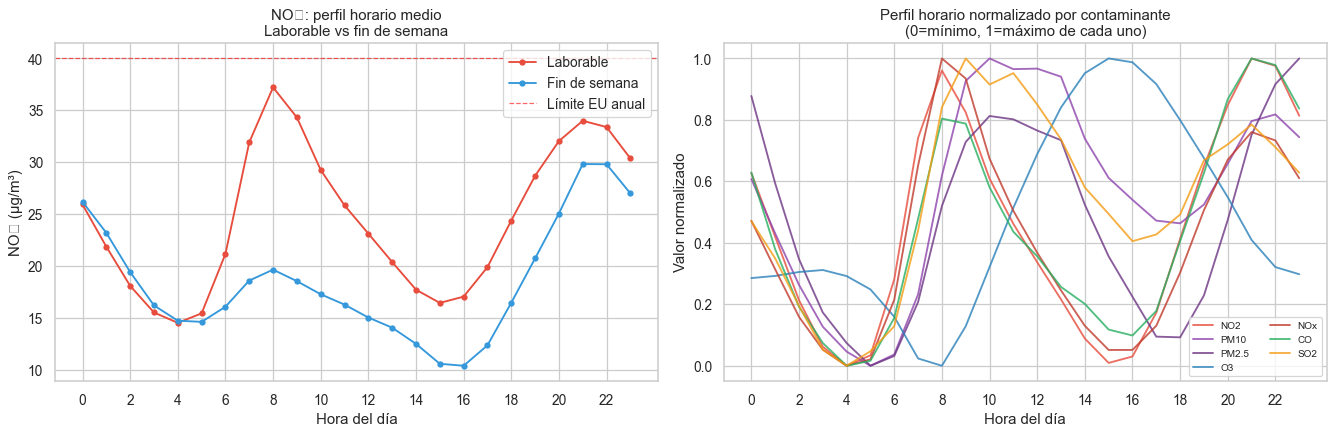

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Perfil horario NO2 — laborable vs fin de semana
no2 = df[df['contaminante'] == 'NO2'].copy()
perfil_hora = no2.groupby(['hora', 'es_fin_semana'])['valor'].mean().unstack()
perfil_hora.columns = ['Laborable', 'Fin de semana']

ax = axes[0]
perfil_hora.plot(ax=ax, marker='o', markersize=4,
                 color=['#e74c3c', '#3498db'])
ax.set_title('NO₂: perfil horario medio\nLaborable vs fin de semana', fontsize=12)
ax.set_xlabel('Hora del día')
ax.set_ylabel('NO₂ (µg/m³)')
ax.set_xticks(range(0, 24, 2))
ax.axhline(40, color='red', linestyle='--', linewidth=1, alpha=0.6, label='Límite EU anual')
ax.legend()

# Perfil horario para todos los contaminantes principales
ax2 = axes[1]
for cont in CONTAMINANTES_PRINCIPALES:
    sub = df[df['contaminante'] == cont]
    if len(sub) > 0:
        perfil = sub.groupby('hora')['valor'].mean()
        # Normalizar 0-1 para poder comparar en misma escala
        perfil_norm = (perfil - perfil.min()) / (perfil.max() - perfil.min() + 1e-9)
        ax2.plot(perfil_norm.index, perfil_norm.values,
                 label=cont, color=COLORES_CONTAMINANTES.get(cont, 'gray'),
                 alpha=0.8, linewidth=1.5)

ax2.set_title('Perfil horario normalizado por contaminante\n(0=mínimo, 1=máximo de cada uno)', fontsize=12)
ax2.set_xlabel('Hora del día')
ax2.set_ylabel('Valor normalizado')
ax2.set_xticks(range(0, 24, 2))
ax2.legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.show()

### 3.2 Perfil por día de la semana

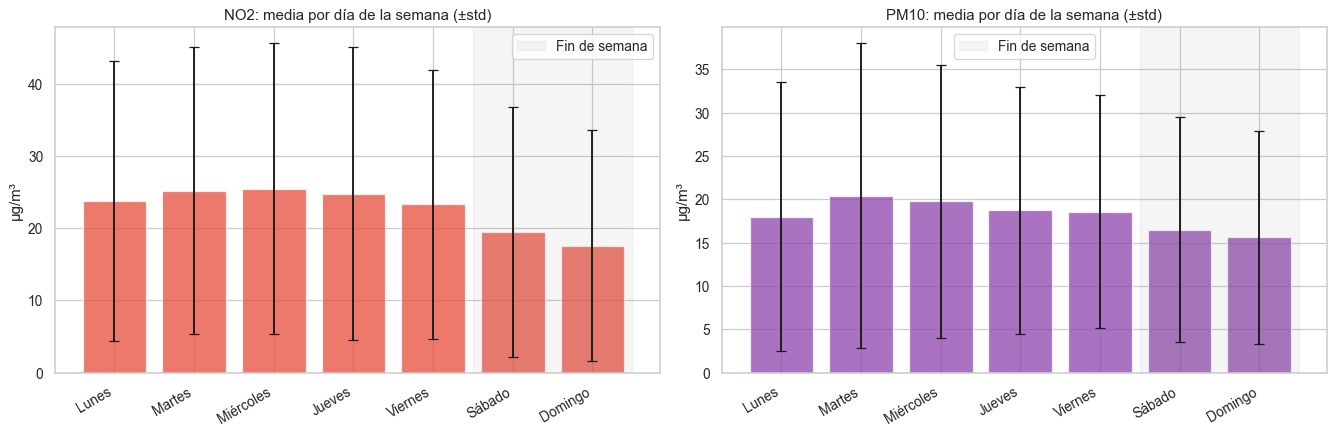

In [5]:
dias_nombres = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, cont in zip(axes, ['NO2', 'PM10']):
    sub = df[df['contaminante'] == cont]
    perfil_dia = sub.groupby('dia_semana')['valor'].agg(['mean', 'std'])
    color = COLORES_CONTAMINANTES.get(cont, 'steelblue')

    ax.bar(range(7), perfil_dia['mean'], yerr=perfil_dia['std'],
           color=color, alpha=0.75, capsize=4, edgecolor='white')
    ax.set_xticks(range(7))
    ax.set_xticklabels(dias_nombres, rotation=30, ha='right')
    ax.set_title(f'{cont}: media por día de la semana (±std)', fontsize=12)
    ax.set_ylabel('µg/m³')
    # Sombrear fin de semana
    ax.axvspan(4.5, 6.5, alpha=0.08, color='gray', label='Fin de semana')
    ax.legend()

plt.tight_layout()
plt.show()

### 3.3 Estacionalidad mensual

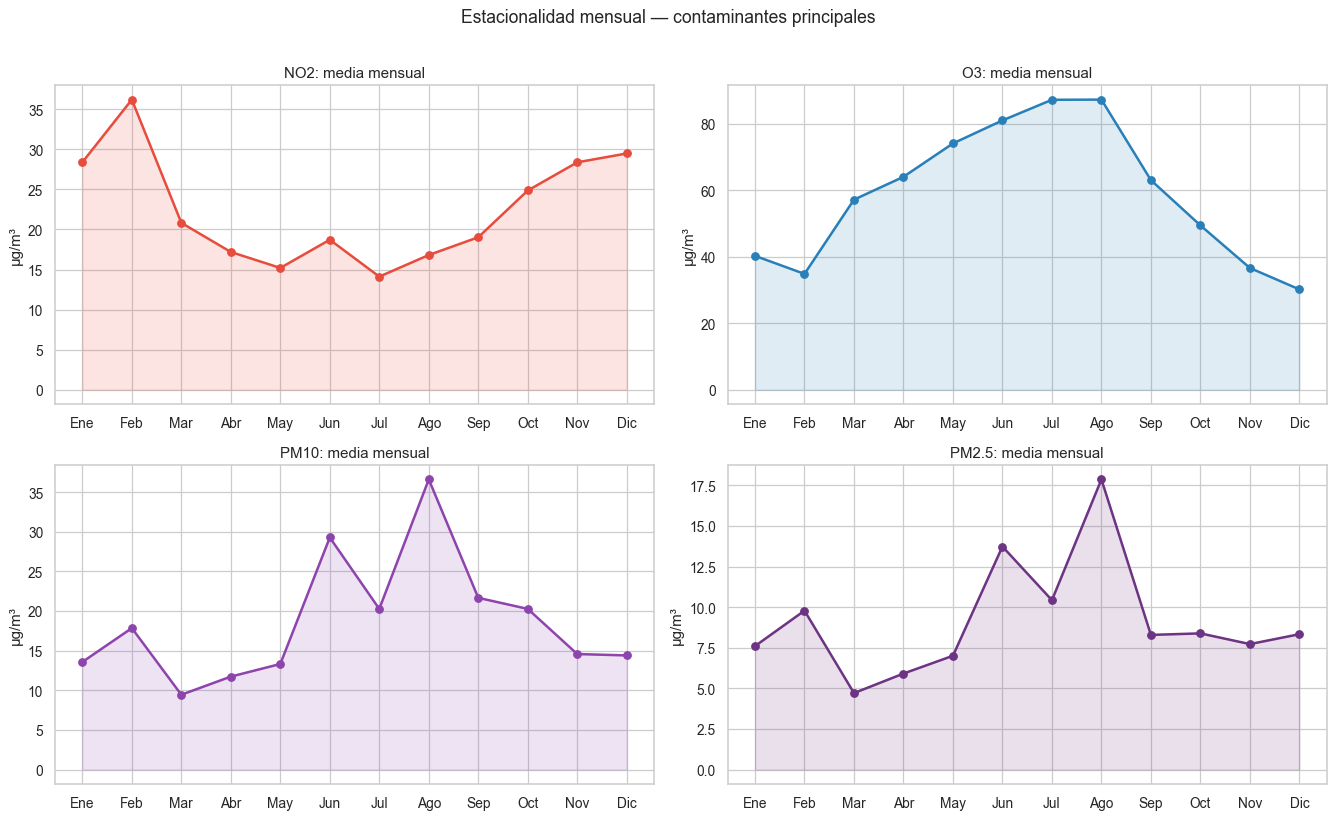

In [41]:
meses_nombres = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun',
                 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
contaminantes_plot = ['NO2', 'O3', 'PM10', 'PM2.5']

for ax, cont in zip(axes.flatten(), contaminantes_plot):
    sub = df[df['contaminante'] == cont]
    if len(sub) == 0:
        continue
    perfil_mes = sub.groupby('mes')['valor'].mean()
    color = COLORES_CONTAMINANTES.get(cont, 'steelblue')

    ax.plot(perfil_mes.index, perfil_mes.values,
            marker='o', color=color, linewidth=2, markersize=6)
    ax.fill_between(perfil_mes.index, perfil_mes.values, alpha=0.15, color=color)
    ax.set_xticks(perfil_mes.index)
    ax.set_xticklabels([meses_nombres[m-1] for m in perfil_mes.index])
    ax.set_title(f'{cont}: media mensual', fontsize=12)
    ax.set_ylabel('µg/m³')

plt.suptitle('Estacionalidad mensual — contaminantes principales', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 3.4 Serie temporal completa — visión global

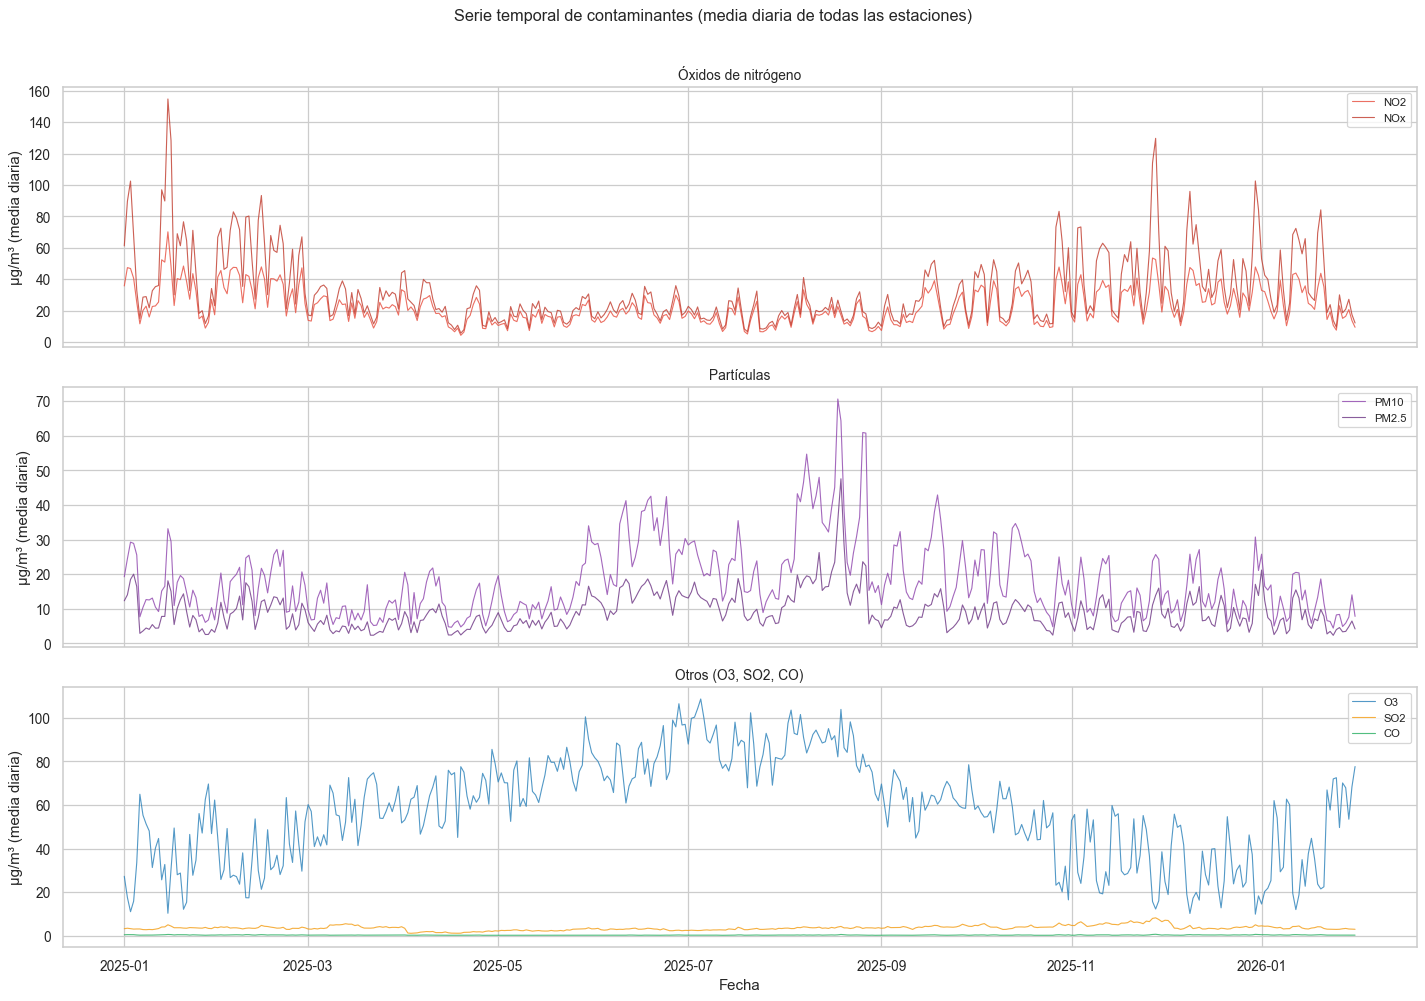

In [42]:
# Resample diario para la serie temporal global
fig, axes = plt.subplots(3, 1, figsize=(16, 11), sharex=True)

grupos = [
    (['NO2', 'NOx'], 'Óxidos de nitrógeno'),
    (['PM10', 'PM2.5'], 'Partículas'),
    (['O3', 'SO2', 'CO'], 'Otros (O3, SO2, CO)'),
]

for ax, (conts, titulo) in zip(axes, grupos):
    for cont in conts:
        sub = df[df['contaminante'] == cont].copy()
        if len(sub) == 0:
            continue
        serie_diaria = sub.set_index('fecha_hora')['valor'].resample('D').mean()
        ax.plot(serie_diaria.index, serie_diaria.values,
                label=cont, alpha=0.8,
                color=COLORES_CONTAMINANTES.get(cont, 'gray'),
                linewidth=0.9)
    ax.set_title(titulo, fontsize=11)
    ax.set_ylabel('µg/m³ (media diaria)')
    ax.legend(fontsize=9)

axes[-1].set_xlabel('Fecha')
plt.suptitle('Serie temporal de contaminantes (media diaria de todas las estaciones)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## 4. Conclusiones

### Dataset
- **1,207,368 observaciones** horarias, sin nulos, período enero 2025 – enero 2026.
- 24 estaciones, 11 contaminantes. No todas las estaciones miden todos los contaminantes.

### Patrones clave identificados
- **NO₂**: dos picos diarios claros (7-9h y 20-22h) coincidentes con horas punta de tráfico. Fin de semana ~20% más bajo que laborable. Invierno más alto que verano.
- **O₃**: perfil inverso al NO₂ (pico a mediodía, mínimo de madrugada). Verano mucho más alto. Correlación negativa con NO₂ (r ≈ -0.5), consistente con química fotoquímica.
- **PM10/PM2.5**: menos estacionalidad, más influenciados por episodios puntuales (Calima sahariana, etc.).
- **Estaciones de tráfico** muestran NO₂ consistentemente más alto (~2x) que estaciones de fondo y suburbanas.

### Implicaciones para el modelo de anomalías
- El perfil normal de cada estación + contaminante es **muy específico** (hora, día semana, mes). El modelo debe aprender estos perfiles por separado.
- Los ceros pueden ser legítimos (O₃ de madrugada) o indicadores de sensor caído: necesitamos distinguirlos.
- Los outliers extremos en NOx (hasta 898 µg/m³) y NO (487 µg/m³) pueden ser eventos reales o fallos de sensor — punto clave para la detección de anomalías.

### Siguiente paso
→ `02_anomaly_detection.ipynb`: entrenar Isolation Forest por estación × contaminante.